## Sentiment Analysis on US Airline Reviews

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense, Dropout, SpatialDropout1D
from tensorflow.keras.layers import Embedding



load dataset

In [2]:
df = load_dataset("stanfordnlp/imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
dataset=df
# Convert train split into dataframe
train_df = pd.DataFrame(dataset["train"])

# Convert test split into dataframe
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

print(train_df.shape)
print(test_df.shape)

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0
(25000, 2)
(25000, 2)


In [5]:
y_train = train_df["label"].values
y_test = test_df["label"].values

In [6]:
X_train = train_df["text"].values
X_test = test_df["text"].values

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1

X_train_seq = tokenizer.texts_to_sequences(
    X_train
)

X_test_seq = tokenizer.texts_to_sequences(
    X_test
)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=250,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=250,
    padding="post",
    truncating="post"
)

In [7]:
embedding_vector_length = 32
model = Sequential()
model.add(Embedding(vocab_size, embedding_vector_length, input_length=200) )
model.add(SpatialDropout1D(0.25))
model.add(LSTM(50, dropout=0.5, recurrent_dropout=0.5))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
history = model.fit(

    X_train_pad,

    y_train,

    validation_data=(
        X_test_pad,
        y_test
    ),

    epochs=5,

    batch_size=32
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 786s 994ms/step - accuracy: 0.5114 - loss: 0.6934 - val_accuracy: 0.5278 - val_loss: 0.6923
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 772s 988ms/step - accuracy: 0.5315 - loss: 0.6915 - val_accuracy: 0.5172 - val_loss: 0.6909
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 770s 985ms/step - accuracy: 0.5474 - loss: 0.6820 - val_accuracy: 0.5521 - val_loss: 0.6706
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 814s 1s/step - accuracy: 0.5786 - loss: 0.6539 - val_accuracy: 0.5595 - val_loss: 0.6634
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 793s 1s/step - accuracy: 0.5883 - loss: 0.6325 - val_accuracy: 0.5618 - val_loss: 0.6679


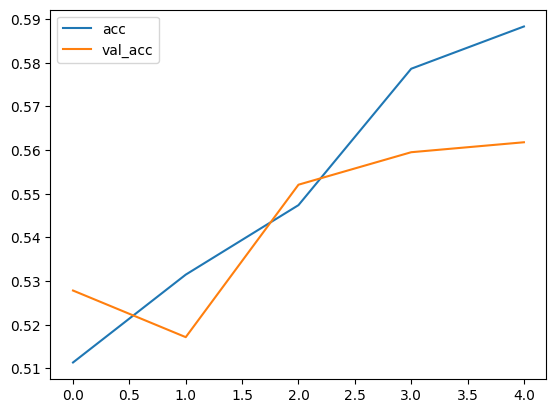

<Figure size 640x480 with 0 Axes>

In [9]:
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()
plt.savefig("Accuracy plot.jpg")

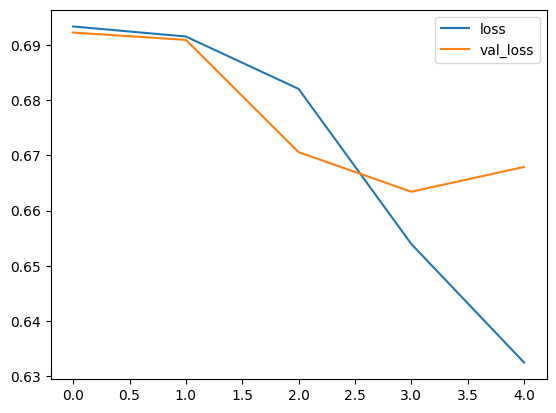

<Figure size 640x480 with 0 Axes>

In [10]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()
plt.savefig("Loss plot.jpg")

In [11]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 128s 163ms/step - accuracy: 0.5618 - loss: 0.6679
Test Loss : 0.6678952574729919
Test Accuracy : 0.5618000030517578


In [12]:
def predict_sentiment(text):

    seq = tokenizer.texts_to_sequences(
        [text]
    )

    padded = pad_sequences(
        seq,
        maxlen=250,
        padding="post",
        truncating="post"
    )

    prediction = model.predict(
        padded,
        verbose=0
    )[0][0]

    sentiment = (
        "Positive"
        if prediction >= 0.5
        else "Negative"
    )

    print(
        f"Sentiment: {sentiment}"
    )

    print(
        f"Confidence: {prediction:.4f}"
    )

In [13]:
test_sentence1 = "I enjoyed my journey on this flight."
predict_sentiment(test_sentence1)

test_sentence2 = "This is the worst flight experience of my life!"
predict_sentiment(test_sentence2)

Sentiment: Positive
Confidence: 0.5011
Sentiment: Positive
Confidence: 0.5011
